# Revision #01 - Graphs and Supplementary Analisys

In [26]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np

In [6]:
df = pd.read_csv('../raw/databases_rna_sugarcane.csv')
df_libtype = pd.read_csv('../raw/libtype.csv')

In [14]:
# Include "libType" column in the main dataframe based in the "Run" column
df = df.merge(
    df_libtype[["sra_id", "libType"]],
    left_on="Run",
    right_on="sra_id",
    how="left"
).drop(columns="sra_id")

In [17]:
Counter(df["libType"])

Counter({'ISR': 1675, 'IU': 1596, 'ISF': 78, nan: 19, 'SF': 2, 'SR': 2})

/tmp/ipykernel_21488/2704068818.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


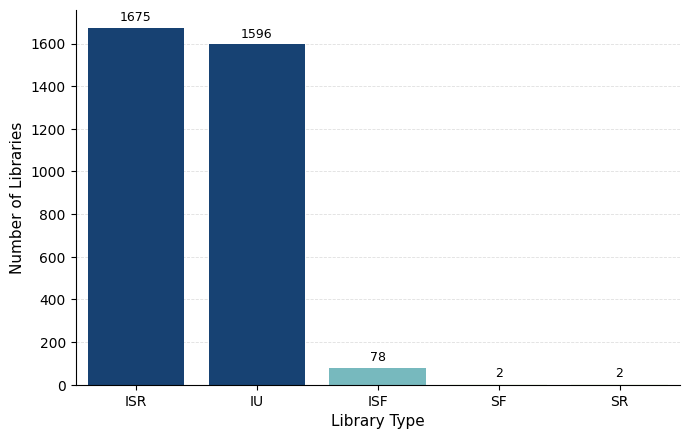

In [28]:
# Remove NaN
plot_df = df.dropna(subset=["libType"])

# Counts
data_libtypes = (
    plot_df["libType"]
    .value_counts()
    .rename_axis("libType")
    .reset_index(name="count")
)

data_libtypes_sorted = data_libtypes.sort_values(
    "count",
    ascending=False
)

# Log normalization
norm = mcolors.LogNorm(
    vmin=data_libtypes_sorted["count"].min(),
    vmax=data_libtypes_sorted["count"].max()
)

cmap = plt.get_cmap("GnBu")

bar_colors = [
    cmap(norm(valor))
    for valor in data_libtypes_sorted["count"]
]

# Figure
fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(
    data=data_libtypes_sorted,
    x="libType",
    y="count",
    palette=bar_colors,
    ax=ax
)

# Labels
ax.set_xlabel("Library Type", fontsize=11)
ax.set_ylabel("Number of Libraries", fontsize=11)

# Values
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3,
        fontsize=9
    )

# Scientific style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4
)

ax.set_axisbelow(True)
ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()

plt.savefig(
    "library_type_distribution.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()